# Lab 2: Predicting Price and Quantities

## Why Prediction Matters for Causal Inference

Before estimating causal effects, we need to assess how well we can predict the outcome and treatment from the available controls. Under the structural equation model, the quantity and price signals are generated by
$$Q_{it} = a_t(S_{it}, \epsilon_{it})\,P_{it} + q_t(S_{it}, \epsilon_{it}), \qquad P_{it} = p_t(S_{it}, \epsilon^p_{it}),$$
where $S_{it} := (X_{it})$ is the state vector containing product characteristics $X_{it}$.

In the double machine learning (DML) framework, the quality of the causal estimate depends directly on how well the nuisance functions
$$\gamma^Q_t(S_{it}) = E[Q_{it} \mid S_{it}], \qquad \gamma^P_t(S_{it}) = E[P_{it} \mid S_{it}]$$
are estimated. These predictions feed into the partially linear regression (PLR) model
$$Q_{it}^\perp = \delta_t\,P_{it}^\perp + e_{it},$$
where $Q_{it}^\perp = Q_{it} - E[Q_{it} \mid S_{it}]$ and $P_{it}^\perp = P_{it} - E[P_{it} \mid S_{it}]$ are residuals. Better nuisance estimation means tighter residuals and more precise estimation of the causal parameter $\delta_t$.

We considers two types of control function specifications:
- **Linear**: $\gamma_t(S_{it}) = g_t^T S_{it}$
- **Nonlinear**: $\gamma_t(S_{it})$ approximated nonparametrically by boosted trees

## Setup

We compare three feature specifications:

1. Tabular controls only
2. The above, plus five PCA components of the embedding vectors
3. The above (without PCA), plus five cosine similarity scores to cluster centroids

For each specification we fit an OLS regression (linear) and a gradient boosted tree model (LightGBM, nonlinear) and report the out-of-sample $R^2$ on the test set.

In [ ]:
import re
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.metrics import pairwise_distances, r2_score

palette = sns.color_palette("colorblind")

## 1. Load Data

In [ ]:
df_train = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_train.zip")
df_test = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_val.zip")

print(f"Train: {df_train.shape}  |  Test: {df_test.shape}")

Train: (41945, 348)  |  Test: (41832, 348)


## 2. Check Embedding Features

We use features based on centered and normalized embeddings. All transformations are fitted on the training set and applied to both sets.

In [ ]:
pca_cols = [f"pca_{i}" for i in range(5)]
sim_cols = [f"similarity_cluster_{i}" for i in range(5)]

print(f"PCA columns: {pca_cols}")
print(df_test[pca_cols].head())
print(f"Similarity columns: {sim_cols}")
print(df_test[sim_cols].head())

PCA columns: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
      pca_0     pca_1     pca_2     pca_3     pca_4
0  0.048269 -0.726435 -0.025251  0.170686  0.070860
1  0.048269 -0.726435 -0.025251  0.170686  0.070860
2  0.048269 -0.726435 -0.025251  0.170686  0.070860
3  0.044607 -0.726271 -0.032725  0.165358  0.071115
4  0.044607 -0.726271 -0.032725  0.165358  0.071115
Similarity columns: ['similarity_cluster_0', 'similarity_cluster_1', 'similarity_cluster_2', 'similarity_cluster_3', 'similarity_cluster_4']
   similarity_cluster_0  similarity_cluster_1  similarity_cluster_2  \
0             -0.427115              0.448444              0.475884   
1             -0.427115              0.448444              0.475884   
2             -0.427115              0.448444              0.475884   
3             -0.426929              0.444972              0.476248   
4             -0.426929              0.444972              0.476248   

   similarity_cluster_3  similarity_cluster_4  
0            

## 3. Construct Dummies

 We add subcategory and time fixed effects as dummy variables.

In [ ]:
subcat_cols = [
 'Airplanes.1',
 'Cars & Race Cars.1',
 'Motor Vehicles.1',
 'Race Tracks.1',
 'Residual.1',
 'Skateboards.1',
 'Tractors.1',
 'Train Sets.1',
 'Trains & Trams.1',
 'Trucks.1',
 'Vehicle Playsets.1',
]

time_cols = [
 '2023-01-30',
 '2023-02-27',
 '2023-03-27',
 '2023-04-24',
 '2023-05-22',
 '2023-06-19',
 '2023-07-17',
 '2023-08-14',
 '2023-09-11',
 '2023-10-09',
 '2023-11-06',
 '2023-12-04',
 '2024-01-01',
 '2024-01-29',
]

print(df_test[subcat_cols].head())
print(df_test[time_cols].head())

   Airplanes.1  Cars & Race Cars.1  Motor Vehicles.1  Race Tracks.1  \
0            0                   0                 0              0   
1            0                   0                 0              0   
2            0                   0                 0              0   
3            0                   0                 0              0   
4            0                   0                 0              0   

   Residual.1  Skateboards.1  Tractors.1  Train Sets.1  Trains & Trams.1  \
0           1              0           0             0                 0   
1           1              0           0             0                 0   
2           1              0           0             0                 0   
3           1              0           0             0                 0   
4           1              0           0             0                 0   

   Trucks.1  Vehicle Playsets.1  
0         0                   0  
1         0                   0  
2         0   

## 4. Define Feature Specifications

### Connection to the Causal Model

The three feature specifications below correspond to different enrichments of the state vector $S_{it} = (Q_{i,t-1}, P_{i,t-1}, X_{it})$. The **Tabular** specification uses only structured controls $X^o_{it}$ (subcategory, time dummies, marketplace variables). Adding **PCA** includes $X^{pc}_i = (\gamma_k^T X^e_i)_{k=1}^5$; adding **Sim** includes $X^{sim}_i = (c_k^T X^e_i)_{k=1}^5$. The richer the state, the more confounding the nuisance models $\gamma^Q_t(S_{it})$ and $\gamma^P_t(S_{it})$ can absorb, leading to less biased residuals for the second-stage causal regression in Lab 3.

In [ ]:
outcome   = "Q_t"
treatment = "P_bb_t"

tabular_candidates = [
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
]
tabular_controls = [c for c in tabular_candidates if c in df_train.columns]
base_controls    = tabular_controls + subcat_cols + time_cols

feature_specs = {
    "Tabular":           base_controls,
    "Tabular + PCA":     base_controls + pca_cols,
    "Tabular + Sim":     base_controls + sim_cols,
}

print(f"Base controls: {len(base_controls)} variables")
print(f"PCA controls:  {len(pca_cols)} additional variables")
print(f"Sim controls:  {len(sim_cols)} additional variables")

Base controls: 30 variables
PCA controls:  5 additional variables
Sim controls:  5 additional variables


In [ ]:
print(base_controls)

['New Offer Count: Current', 'Count of retrieved live offers: New, FBA', 'Count of retrieved live offers: New, FBM', 'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA', 'Airplanes.1', 'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1', 'Skateboards.1', 'Tractors.1', 'Train Sets.1', 'Trains & Trams.1', 'Trucks.1', 'Vehicle Playsets.1', '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


## 5. Estimate Prediction Models

We fit each model on the training set and evaluate it on the test set. Because observations from the same product are serially correlated, we do not use the training $R^2$ as a measure of fit quality. The test-set $R^2$ is what matters for the downstream causal estimator.

In [ ]:
def build_X_ols(df, controls):
    cols = [c for c in controls if c in df.columns]
    X = df[cols].fillna(0).copy()
    X.columns = [re.sub(r"[^A-Za-z0-9_]+", "", c) for c in X.columns]
    return sm.add_constant(X, has_constant="add")

def build_X_lgbm(df, controls):
    cols = [c for c in controls if c in df.columns]
    X = df[cols].fillna(0).copy()
    X.columns = [re.sub(r"[^A-Za-z0-9_]+", "", c) for c in X.columns]
    return X

results = []

for spec_name, controls in feature_specs.items():
    print(f"\n{'='*60}")
    print(f"  {spec_name}")
    print(f"{'='*60}")

    # OLS
    X_tr = build_X_ols(df_train, controls)
    X_te = build_X_ols(df_test,  controls).reindex(columns=X_tr.columns, fill_value=0)

    ols_q = sm.OLS(df_train[outcome],   X_tr).fit()
    ols_p = sm.OLS(df_train[treatment], X_tr).fit()

    r2_q_tr = r2_score(df_train[outcome],   ols_q.predict(X_tr))
    r2_q_te = r2_score(df_test[outcome],    ols_q.predict(X_te))
    r2_p_tr = r2_score(df_train[treatment], ols_p.predict(X_tr))
    r2_p_te = r2_score(df_test[treatment],  ols_p.predict(X_te))
    print(f"  OLS       Q: train {r2_q_tr:.4f}  test {r2_q_te:.4f}    "
          f"P: train {r2_p_tr:.4f}  test {r2_p_te:.4f}")
    results.append({"Specification": spec_name, "Model": "OLS",
                    "R2 Q Train": r2_q_tr, "R2 Q Test": r2_q_te,
                    "R2 P Train": r2_p_tr, "R2 P Test": r2_p_te})

    # LightGBM
    Xl_tr = build_X_lgbm(df_train, controls)
    Xl_te = build_X_lgbm(df_test,  controls).reindex(columns=Xl_tr.columns, fill_value=0)

    lgbm_q = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    lgbm_q.fit(Xl_tr, df_train[outcome])
    lgbm_p = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    lgbm_p.fit(Xl_tr, df_train[treatment])

    r2_q_tr = r2_score(df_train[outcome],   lgbm_q.predict(Xl_tr))
    r2_q_te = r2_score(df_test[outcome],    lgbm_q.predict(Xl_te))
    r2_p_tr = r2_score(df_train[treatment], lgbm_p.predict(Xl_tr))
    r2_p_te = r2_score(df_test[treatment],  lgbm_p.predict(Xl_te))
    print(f"  LightGBM  Q: train {r2_q_tr:.4f}  test {r2_q_te:.4f}    "
          f"P: train {r2_p_tr:.4f}  test {r2_p_te:.4f}")
    results.append({"Specification": spec_name, "Model": "LightGBM",
                    "R2 Q Train": r2_q_tr, "R2 Q Test": r2_q_te,
                    "R2 P Train": r2_p_tr, "R2 P Test": r2_p_te})

df_results = pd.DataFrame(results).set_index(["Specification", "Model"])


  Tabular
  OLS       Q: train 0.0750  test 0.0619    P: train 0.1567  test 0.1582
  LightGBM  Q: train 0.2872  test 0.0925    P: train 0.3768  test 0.1856

  Tabular + PCA
  OLS       Q: train 0.6880  test 0.3995    P: train 0.7924  test 0.6061
  LightGBM  Q: train 0.8246  test 0.4521    P: train 0.9450  test 0.6412

  Tabular + Sim
  OLS       Q: train 0.6897  test 0.4117    P: train 0.7645  test 0.5714
  LightGBM  Q: train 0.8128  test 0.4329    P: train 0.9291  test 0.6321


## 6. Results

The table below reports test-set $R^2$ values, expressed as percentages. Notice that embedding features consistently improve fit over the tabular baseline. This is important: better prediction of both $Q_{it}$ and $P_{it}$ from the controls means tighter residuals and more precise causal estimates downstream.

The CACE $\alpha_t(S_{it})$ is identified by the CAPE $\delta_t(S_{it})$, provided the nuisance functions $\gamma^Q_t(S_{it})$ and $\gamma^P_t(S_{it})$ are estimated consistently. The $R^2$ values in the table directly measure how well these nuisance functions are estimated.

In [ ]:
display_cols = ["R2 Q Test", "R2 P Test"]
print("Test-set R2 (%)")
(df_results[display_cols] * 100).round(2)

Test-set R2 (%)


R2 Q Test  R2 P Test
Specification Model                         
Tabular       OLS            6.19      15.82
              LightGBM       9.25      18.56
Tabular + PCA OLS           39.95      60.61
              LightGBM      45.21      64.12
Tabular + Sim OLS           41.17      57.14
              LightGBM      43.29      63.21

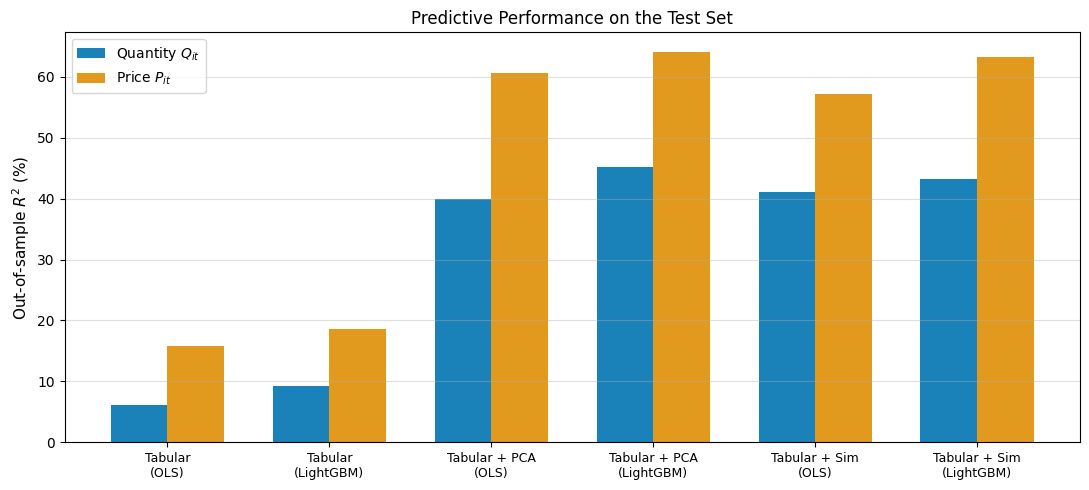

In [ ]:
df_plot = df_results.reset_index()
df_plot["label"] = df_plot["Specification"] + "\n(" + df_plot["Model"] + ")"

x = np.arange(len(df_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, df_plot["R2 Q Test"] * 100, w,
       label="Quantity $Q_{it}$",  color=palette[0], alpha=0.9)
ax.bar(x + w/2, df_plot["R2 P Test"] * 100, w,
       label="Price $P_{it}$", color=palette[1], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"], fontsize=9)
ax.set_ylabel("Out-of-sample $R^2$ (%)", fontsize=11)
ax.set_title("Predictive Performance on the Test Set", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Discussion

Several patterns are worth noting.

First, predicting quantity to be harder than price.

Second, boosted trees consistently outperform OLS. The state space is high-dimensional and the relationship between controls and outcomes is likely nonlinear. Tree-based methods handle both without requiring us to specify the functional form.